In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# ========================================================
# END-TO-END CUSTOMER CHURN PREDICTION PROJECT
# ========================================================
# Problem: Telecom company wants to predict if a customer will churn (Yes/No)
# Features: Categorical + Numerical + TEXT feedback (CustomerFeedback)
#
# Techniques Compared (All 3 methods):
#   1. OneHotEncoding only  (for categorical columns)
#   2. OneHotEncoding + BOW (Bag of Words using CountVectorizer on text)
#   3. OneHotEncoding + TF-IDF (using TfidfVectorizer on text)
#
# We train all three pipelines, compare accuracy on test set,
# automatically select the BEST performing method,
# and use that best model for any future / new dataset.
# Data: 150 realistic synthetic records
# ========================================================

# ====================== STEP 1: Generate 150 Records ======================
print("=== STEP 1: Creating 150 synthetic customer records ===")

np.random.seed(42)

n_samples = 150

data = {
    'Gender': np.random.choice(['Male', 'Female'], n_samples),
    'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], n_samples, p=[0.55, 0.30, 0.15]),
    'PaymentMethod': np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], n_samples),
    'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], n_samples, p=[0.35, 0.50, 0.15]),
    'Tenure': np.random.randint(1, 73, n_samples),
    'MonthlyCharges': np.round(np.random.uniform(20, 120, n_samples), 2),
}

# TEXT column for BOW and TF-IDF
feedback_options = [
    "Great service and fast speeds",
    "Poor network connection keeps dropping",
    "Excellent customer support",
    "Billing errors every month",
    "Love the pricing and value",
    "Slow internet during peak hours",
    "Happy with the overall experience",
    "Contract is too expensive",
    "Frequent network outages",
    "Very satisfied with fiber optic",
    "Support team never responds",
    "Switched due to better offers",
    "Reliable connection and good speed",
    "Too many hidden charges",
    "Best internet service provider"
]
data['CustomerFeedback'] = np.random.choice(feedback_options, n_samples)

df = pd.DataFrame(data)
display(df.head())

=== STEP 1: Creating 150 synthetic customer records ===


,Gender,Contract,PaymentMethod,InternetService,Tenure,MonthlyCharges,CustomerFeedback
0,Male,One year,Mailed check,DSL,61,32.80,Happy with the overall experience
1,Female,One year,Mailed check,Fiber optic,54,35.19,Contract is too expensive
2,Male,Month-to-month,Mailed check,Fiber optic,39,33.88,Too many hidden charges
3,Male,Month-to-month,Mailed check,Fiber optic,19,84.09,Excellent customer support
4,Male,Month-to-month,Electronic check,Fiber optic,39,38.19,Reliable connection and good speed


In [5]:
high_churn = (df['Tenure'] < 12) | (df['MonthlyCharges'] > 80)

type(high_churn)

pandas.Series

In [6]:
df['Churn'] = np.where(
    high_churn,
    np.random.choice(['Yes', 'No'], n_samples, p=[0.75, 0.25]),
    np.random.choice(['Yes', 'No'], n_samples, p=[0.20, 0.80])
)
display(df.head())

,Gender,Contract,PaymentMethod,InternetService,Tenure,MonthlyCharges,CustomerFeedback,Churn
0,Male,One year,Mailed check,DSL,61,32.80,Happy with the overall experience,No
1,Female,One year,Mailed check,Fiber optic,54,35.19,Contract is too expensive,No
2,Male,Month-to-month,Mailed check,Fiber optic,39,33.88,Too many hidden charges,No
3,Male,Month-to-month,Mailed check,Fiber optic,19,84.09,Excellent customer support,Yes
4,Male,Month-to-month,Electronic check,Fiber optic,39,38.19,Reliable connection and good speed,No


In [8]:
df['high_churn'] = (df['Tenure'] < 12) | (df['MonthlyCharges'] > 80)
display(df.head())

,Gender,Contract,PaymentMethod,InternetService,Tenure,MonthlyCharges,CustomerFeedback,high_churn
0,Male,One year,Mailed check,DSL,61,32.80,Happy with the overall experience,False
1,Female,One year,Mailed check,Fiber optic,54,35.19,Contract is too expensive,False
2,Male,Month-to-month,Mailed check,Fiber optic,39,33.88,Too many hidden charges,False
3,Male,Month-to-month,Mailed check,Fiber optic,19,84.09,Excellent customer support,True
4,Male,Month-to-month,Electronic check,Fiber optic,39,38.19,Reliable connection and good speed,False


In [9]:
df['Churn'] = np.where(
    df['high_churn'],
    np.random.choice(['Yes', 'No'], n_samples, p=[0.75, 0.25]),
    np.random.choice(['Yes', 'No'], n_samples, p=[0.20, 0.80])
)
display(df.head())

,Gender,Contract,PaymentMethod,InternetService,Tenure,MonthlyCharges,CustomerFeedback,high_churn,Churn
0,Male,One year,Mailed check,DSL,61,32.80,Happy with the overall experience,False,No
1,Female,One year,Mailed check,Fiber optic,54,35.19,Contract is too expensive,False,No
2,Male,Month-to-month,Mailed check,Fiber optic,39,33.88,Too many hidden charges,False,No
3,Male,Month-to-month,Mailed check,Fiber optic,19,84.09,Excellent customer support,True,Yes
4,Male,Month-to-month,Electronic check,Fiber optic,39,38.19,Reliable connection and good speed,False,No


In [10]:
print(f"Total records: {df.shape[0]}")
print(df.head())
print("\nChurn distribution:\n", df['Churn'].value_counts())

Total records: 150
   Gender        Contract     PaymentMethod InternetService  Tenure  \
0    Male        One year      Mailed check             DSL      61   
1  Female        One year      Mailed check     Fiber optic      54   
2    Male  Month-to-month      Mailed check     Fiber optic      39   
3    Male  Month-to-month      Mailed check     Fiber optic      19   
4    Male  Month-to-month  Electronic check     Fiber optic      39   

   MonthlyCharges                    CustomerFeedback  high_churn Churn  
0           32.80   Happy with the overall experience       False    No  
1           35.19           Contract is too expensive       False    No  
2           33.88             Too many hidden charges       False    No  
3           84.09          Excellent customer support        True   Yes  
4           38.19  Reliable connection and good speed       False    No  

Churn distribution:
 Churn
No     87
Yes    63
Name: count, dtype: int64


In [11]:
X = df.drop('Churn', axis=1)
display(X)
y = df['Churn']
display(y)

,Gender,Contract,PaymentMethod,InternetService,Tenure,MonthlyCharges,CustomerFeedback,high_churn
0,Male,One year,Mailed check,DSL,61,32.80,Happy with the overall experience,False
1,Female,One year,Mailed check,Fiber optic,54,35.19,Contract is too expensive,False
2,Male,Month-to-month,Mailed check,Fiber optic,39,33.88,Too many hidden charges,False
3,Male,Month-to-month,Mailed check,Fiber optic,19,84.09,Excellent customer support,True
4,Male,Month-to-month,Electronic check,Fiber optic,39,38.19,Reliable connection and good speed,False
...,...,...,...,...,...,...,...,...
145,Male,One year,Credit card,No,6,72.31,Slow internet during peak hours,True
146,Male,One year,Electronic check,No,53,55.88,Happy with the overall experience,False
147,Male,Month-to-month,Bank transfer,Fiber optic,66,107.72,Frequent network outages,True
148,Male,Month-to-month,Credit card,Fiber optic,43,59.24,Great service and fast speeds,False


0       No
1       No
2       No
3      Yes
4       No
      ... 
145    Yes
146     No
147     No
148     No
149     No
Name: Churn, Length: 150, dtype: str

In [12]:
categorical_features = ['Gender', 'Contract', 'PaymentMethod', 'InternetService']
numerical_features   = ['Tenure', 'MonthlyCharges']
text_feature         = 'CustomerFeedback'

In [2]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

data = {
    'Employee id': [10, 20, 15, 25, 30],
    'Gender': ['M', 'F', 'F', 'M', 'F'],
    'Remarks': ['Good', 'Nice', 'Good', 'Great', 'Nice']
}

df = pd.DataFrame(data)
print(f"Original Employee Data:\n{df}\n")
# Use pd.get_dummies() to one-hot encode the categorical columns
df_pandas_encoded = pd.get_dummies(df, columns=['Gender', 'Remarks'], drop_first=True)
print(f"One-Hot Encoded Data using Pandas:\n{df_pandas_encoded}\n")

categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
categorical_columns


Original Employee Data:
   Employee id Gender Remarks
0           10      M    Good
1           20      F    Nice
2           15      F    Good
3           25      M   Great
4           30      F    Nice

One-Hot Encoded Data using Pandas:
   Employee id  Gender_M  Remarks_Great  Remarks_Nice
0           10      True          False         False
1           20     False          False          True
2           15     False          False         False
3           25      True           True         False
4           30     False          False          True



C:\Users\g.peyyala\AppData\Local\Temp\ipykernel_14168\1635330109.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns.tolist()


['Gender', 'Remarks']

In [3]:

encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(df[categorical_columns])
display(one_hot_encoded)
one_hot_df = pd.DataFrame(one_hot_encoded, 
                          columns=encoder.get_feature_names_out(categorical_columns))
display(one_hot_df)
df_sklearn_encoded = pd.concat([df.drop(categorical_columns, axis=1), one_hot_df], axis=1)

print(f"One-Hot Encoded Data using Scikit-Learn:\n{df_sklearn_encoded}\n")

array([[0., 1., 1., 0., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 1., 0., 0.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 0., 1.]])

,Gender_F,Gender_M,Remarks_Good,Remarks_Great,Remarks_Nice
0,0.0,1.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,1.0


One-Hot Encoded Data using Scikit-Learn:
   Employee id  Gender_F  Gender_M  Remarks_Good  Remarks_Great  Remarks_Nice
0           10       0.0       1.0           1.0            0.0           0.0
1           20       1.0       0.0           0.0            0.0           1.0
2           15       1.0       0.0           1.0            0.0           0.0
3           25       0.0       1.0           0.0            1.0           0.0
4           30       1.0       0.0           0.0            0.0           1.0



In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

data = {'Employee id': [10, 20, 15, 25, 30],
        'Gender': ['M', 'F', 'F', 'M', 'F'],
        'Remarks': ['Good', 'Nice', 'Good', 'Great', 'Nice'],
        }
df = pd.DataFrame(data)
print(f"Employee data : \n{df}")

categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(df[categorical_columns])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

df_encoded = pd.concat([df, one_hot_df], axis=1)

df_encoded = df_encoded.drop(categorical_columns, axis=1)
print(f"Encoded Employee data : \n{df_encoded}")

In [6]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

data = {
    'Employee id': [10, 20, 15, 25, 30],
    'Gender': ['M', 'F', 'F', 'M', 'F'],
    'Remarks': ['Good', 'Nice', 'Good', 'Great', 'Nice']
}

df = pd.DataFrame(data)

categorical_columns = df.select_dtypes(include=['object']).columns.to_list()
categorical_columns

C:\Users\g.peyyala\AppData\Local\Temp\ipykernel_14168\4241317.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns.to_list()


['Gender', 'Remarks']

In [ ]:
df_pandas_encoded = pd.get_dummies(df, columns=['Gender', 'Remarks'], drop_first=True)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [
    "Thor eating pizza, Loki is eating pizza, Ironman ate pizza already",
    "Apple is announcing new iphone tomorrow",
    "Tesla is announcing new model-3 tomorrow",
    "Google is announcing new pixel-6 tomorrow",
    "Microsoft is announcing new surface tomorrow",
    "Amazon is announcing new eco-dot tomorrow",
    "I am eating biryani and you are eating grapes"
]

corpus

['Thor eating pizza, Loki is eating pizza, Ironman ate pizza already',
 'Apple is announcing new iphone tomorrow',
 'Tesla is announcing new model-3 tomorrow',
 'Google is announcing new pixel-6 tomorrow',
 'Microsoft is announcing new surface tomorrow',
 'Amazon is announcing new eco-dot tomorrow',
 'I am eating biryani and you are eating grapes']

In [8]:
v = TfidfVectorizer()
output = v.fit_transform(corpus)
output

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 46 stored elements and shape (7, 28)>

In [9]:
v.vocabulary_

{'thor': 25,
 'eating': 10,
 'pizza': 22,
 'loki': 17,
 'is': 16,
 'ironman': 15,
 'ate': 7,
 'already': 0,
 'apple': 5,
 'announcing': 4,
 'new': 20,
 'iphone': 14,
 'tomorrow': 26,
 'tesla': 24,
 'model': 19,
 'google': 12,
 'pixel': 21,
 'microsoft': 18,
 'surface': 23,
 'amazon': 2,
 'eco': 11,
 'dot': 9,
 'am': 1,
 'biryani': 8,
 'and': 3,
 'you': 27,
 'are': 6,
 'grapes': 13}

In [11]:
all_feature_names = v.get_feature_names_out()

In [13]:
for i in all_feature_names:
    index = v.vocabulary_.get(i)
    idf_score = v.idf_[index]

    print(f"{i} : {idf_score}")

already : 2.386294361119891
am : 2.386294361119891
amazon : 2.386294361119891
and : 2.386294361119891
announcing : 1.2876820724517808
apple : 2.386294361119891
are : 2.386294361119891
ate : 2.386294361119891
biryani : 2.386294361119891
dot : 2.386294361119891
eating : 1.9808292530117262
eco : 2.386294361119891
google : 2.386294361119891
grapes : 2.386294361119891
iphone : 2.386294361119891
ironman : 2.386294361119891
is : 1.1335313926245225
loki : 2.386294361119891
microsoft : 2.386294361119891
model : 2.386294361119891
new : 1.2876820724517808
pixel : 2.386294361119891
pizza : 2.386294361119891
surface : 2.386294361119891
tesla : 2.386294361119891
thor : 2.386294361119891
tomorrow : 1.2876820724517808
you : 2.386294361119891


In [15]:
output.toarray()[0]

array([0.24266547, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.24266547, 0.        , 0.        ,
       0.40286636, 0.        , 0.        , 0.        , 0.        ,
       0.24266547, 0.11527033, 0.24266547, 0.        , 0.        ,
       0.        , 0.        , 0.72799642, 0.        , 0.        ,
       0.24266547, 0.        , 0.        ])

In [16]:
import pandas as pd

df= pd.read_csv("Ecommerce_data.csv")
df

,Text,label
0,Urban Ladder Eisner Low Back Study-Office Comp...,Household
1,"Contrast living Wooden Decorative Box,Painted ...",Household
2,IO Crest SY-PCI40010 PCI RAID Host Controller ...,Electronics
3,ISAKAA Baby Socks from Just Born to 8 Years- P...,Clothing & Accessories
4,Indira Designer Women's Art Mysore Silk Saree ...,Clothing & Accessories
...,...,...
23995,Marvel Physics MCQ's for MHT - CET,Books
23996,Internet Download Manager | Lifetime License |...,Books
23997,Sadhubela's Handcrafted Iron Degchi Handi Pot ...,Household
23998,Audio-Technica AT-LP60 Automatic Belt Driven D...,Electronics


In [17]:
df['label'].value_counts()

label
Household                 6000
Electronics               6000
Clothing & Accessories    6000
Books                     6000
Name: count, dtype: int64

In [20]:
df['label_num'] = df['label'].map({'Household': 0, 'Books': 1,'Electronics': 2, 'Clothing & Accessories': 3})
df

,Text,label,label_num
0,Urban Ladder Eisner Low Back Study-Office Comp...,Household,0
1,"Contrast living Wooden Decorative Box,Painted ...",Household,0
2,IO Crest SY-PCI40010 PCI RAID Host Controller ...,Electronics,2
3,ISAKAA Baby Socks from Just Born to 8 Years- P...,Clothing & Accessories,3
4,Indira Designer Women's Art Mysore Silk Saree ...,Clothing & Accessories,3
...,...,...,...
23995,Marvel Physics MCQ's for MHT - CET,Books,1
23996,Internet Download Manager | Lifetime License |...,Books,1
23997,Sadhubela's Handcrafted Iron Degchi Handi Pot ...,Household,0
23998,Audio-Technica AT-LP60 Automatic Belt Driven D...,Electronics,2


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.Text, df.label_num, test_size=0.2, random_state=42, stratify=df.label_num)

In [22]:
X_train.shape

(19200,)

In [23]:
X_test.shape

(4800,)

In [24]:
from sklearn.pipeline import Pipeline 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

t = Pipeline([
    ('v_tfidf', TfidfVectorizer()),
    ('KNN', KNeighborsClassifier())
])

t.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('v_tfidf', ...), ('KNN', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [25]:
y_pred = t.predict(X_test)

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1200
           1       0.96      0.95      0.96      1200
           2       0.97      0.96      0.97      1200
           3       0.98      0.97      0.98      1200

    accuracy                           0.96      4800
   macro avg       0.96      0.96      0.96      4800
weighted avg       0.96      0.96      0.96      4800



In [ ]:
! pip3 install spacy

  Using cached spacy-3.8.13-cp314-cp314-win_amd64.whl.metadata (28 kB)
  Using cached thinc-8.3.13-cp314-cp314-win_amd64.whl.metadata (15 kB)
  Using cached weasel-1.0.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached typer-0.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
Using cached spacy-3.8.13-cp314-cp314-win_amd64.whl (14.4 MB)
Using cached thinc-8.3.13-cp314-cp314-win_amd64.whl (1.7 MB)
Using cached typer-0.25.0-py3-none-any.whl (55 kB)
Using cached weasel-1.0.0-py3-none-any.whl (50 kB)
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)

   ---------------------------------------- 0/5 [httpx]
   ---------------------------------------- 0/5 [httpx]
   ---------------------------------------- 0/5 [httpx]
   ---------------------------------------- 0/5 [httpx]
   ---------------------------------------- 0/5 [httpx]
   ---------------------------------------- 0/5 [httpx]
   ---------------------------------------- 0/5 [httpx]
 


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
   ---------------------------------------- 0.0/14.4 MB ? eta -:--:--
   ----- ---------------------------------- 1.8/14.4 MB 12.4 MB/s eta 0:00:02
   ------------------ --------------------- 6.6/14.4 MB 19.2 MB/s eta 0:00:01
   ------------------------ --------------- 8.7/14.4 MB 15.6 MB/s eta 0:00:01
   ----------------------------- ---------- 10.5/14.4 MB 15.9 MB/s eta 0:00:01
   ----------------------------- ---------- 10.5/14.4 MB 15.9 MB/s eta 0:00:01
   -------------------------------- ------- 11.8/14.4 MB 11.6 MB/s eta 0:00:01
   ---------------------------------- ----- 12.3/14.4 MB 9.0 MB/s eta 0:00:01
   ---------------------------------------  14.2/14.4 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------- 14.4/14.4 MB 8.6 MB/s  0:00:01
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 11.8 MB/s  0:00:00
   --------------


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import spacy

nlp = spacy.load("en_core_web_sm")

def preprocess(text):
    filter_tokens= []
    doc = nlp(text)
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filter_tokens.append(token.lemma_)
    
    return " ".join(filter_tokens)

In [32]:
df

,Text,label,label_num
0,Urban Ladder Eisner Low Back Study-Office Comp...,Household,0
1,"Contrast living Wooden Decorative Box,Painted ...",Household,0
2,IO Crest SY-PCI40010 PCI RAID Host Controller ...,Electronics,2
3,ISAKAA Baby Socks from Just Born to 8 Years- P...,Clothing & Accessories,3
4,Indira Designer Women's Art Mysore Silk Saree ...,Clothing & Accessories,3
...,...,...,...
23995,Marvel Physics MCQ's for MHT - CET,Books,1
23996,Internet Download Manager | Lifetime License |...,Books,1
23997,Sadhubela's Handcrafted Iron Degchi Handi Pot ...,Household,0
23998,Audio-Technica AT-LP60 Automatic Belt Driven D...,Electronics,2


In [33]:
df['preprocessed_text'] = df['Text'].apply(preprocess)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    df.preprocessed_text, 
    df.label_num,
    test_size=0.2, # 20% samples will go to test dataset
    random_state=2022,
    stratify=df.label_num
)

In [36]:
from sklearn.ensemble import RandomForestClassifier

t = Pipeline([
    ('v_tfidf', TfidfVectorizer()),
    ('RForest', RandomForestClassifier())
])

t.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('v_tfidf', ...), ('RForest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [37]:
y_pred = t.predict(X_test)

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1200
           1       0.98      0.98      0.98      1200
           2       0.98      0.97      0.98      1200
           3       0.98      0.99      0.99      1200

    accuracy                           0.98      4800
   macro avg       0.98      0.98      0.98      4800
weighted avg       0.98      0.98      0.98      4800



In [39]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1164,    8,   13,   15],
       [  20, 1171,    6,    3],
       [  20,    8, 1169,    3],
       [   9,    5,    1, 1185]])

Matplotlib is building the font cache; this may take a moment.


Text(95.72222222222221, 0.5, 'Truth')

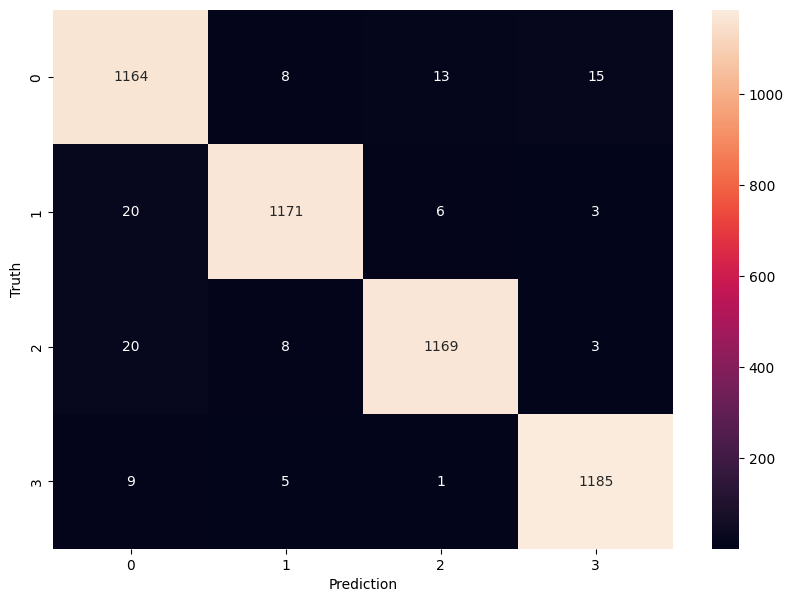

In [41]:
from matplotlib import pyplot as plt
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')